# Sentiment Analysis

Necessary imports

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import kruskal
from pathlib import Path

#  VADER sentiment analysis
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

# visualisation
import matplotlib.pyplot as plt 


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/icedspice/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Loading the cleaned parquet file

In [4]:
# load the cleaned dataset
df = pd.read_parquet("data/bitcoin_tweet_with_topics.parquet")

# structure of dataframe
df.head()

,user_name,user_created,user_followers,user_friends,user_verified,date,text,text_clean,hashtags,mentions,account_age_days,dominant_topic,topic_label,topic_strength,topic_confidence
0,Alal,2022-02-25 04:30:38+00:00,17,179,False,2025-03-06 14:43:39+00:00,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,amazing impressed project hopefully event comm...,[BTC],"[mexcresearch, mexc_fans, mexc_updates, alnahy...",1104,2,Crypto projects and future expectations,0.072240,1.000000
1,Bottle🐐,2015-02-19 08:11:45+00:00,527,307,False,2025-03-06 14:44:05+00:00,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,fud sub wan risk buy prices imo,[BTC],"[iamdonaldyusuf, yuzomausman, aproko_doctor]",3667,0,"Buying, selling and trading behaviour",0.027385,0.847849
2,LowCapVillain,2021-12-30 00:19:52+00:00,108,31,False,2025-03-06 14:44:09+00:00,I personally ignore weekend moves and chill wi...,personally ignore weekend moves chill family,[BTC],[],1161,1,Bitcoin as money and store of value,0.003070,0.502805
3,Millennial Wealth,2021-08-26 00:26:37+00:00,24,86,False,2025-03-06 14:44:23+00:00,Move Digital Energy Through Cyber Space. #Bitc...,digital energy cyber space,"[Bitcoin, BTC]",[],1287,1,Bitcoin as money and store of value,0.006987,0.998150
4,Crypto Don,2020-03-19 17:04:42+00:00,180,908,False,2025-03-06 14:46:23+00:00,"1/2 End of shitcoin season, lasted even longer...",end shitcoin season lasted longer expected fro...,"[cronje, frognation, BTC]",[],1812,3,Ethereum and altcoin discussion,0.022690,0.572949


## VADER Model

In [5]:
sia = SentimentIntensityAnalyzer()

# applies vader sentiment analyzer to cleaned text
# creates new column in df for vader compound score

df["vader_compound"] =  df["text_clean"].astype(str).apply(
    lambda text: sia.polarity_scores(text)["compound"]
)

# function to classify vader compound sentiment scores 

def classify_vader_sentiment(compound) :
    if compound >= 0.05 :
        return "positive"
    elif compound <= -0.05 :
        return "negative"
    else:
        return "neutral"

# creats new column in df for vader classification

df["vader_sentiment"] = df["vader_compound"].apply(classify_vader_sentiment)

df.head()

,user_name,user_created,user_followers,user_friends,user_verified,date,text,text_clean,hashtags,mentions,account_age_days,dominant_topic,topic_label,topic_strength,topic_confidence,vader_compound,vader_sentiment
0,Alal,2022-02-25 04:30:38+00:00,17,179,False,2025-03-06 14:43:39+00:00,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,amazing impressed project hopefully event comm...,[BTC],"[mexcresearch, mexc_fans, mexc_updates, alnahy...",1104,2,Crypto projects and future expectations,0.072240,1.000000,0.9269,positive
1,Bottle🐐,2015-02-19 08:11:45+00:00,527,307,False,2025-03-06 14:44:05+00:00,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,fud sub wan risk buy prices imo,[BTC],"[iamdonaldyusuf, yuzomausman, aproko_doctor]",3667,0,"Buying, selling and trading behaviour",0.027385,0.847849,-0.4939,negative
2,LowCapVillain,2021-12-30 00:19:52+00:00,108,31,False,2025-03-06 14:44:09+00:00,I personally ignore weekend moves and chill wi...,personally ignore weekend moves chill family,[BTC],[],1161,1,Bitcoin as money and store of value,0.003070,0.502805,-0.3612,negative
3,Millennial Wealth,2021-08-26 00:26:37+00:00,24,86,False,2025-03-06 14:44:23+00:00,Move Digital Energy Through Cyber Space. #Bitc...,digital energy cyber space,"[Bitcoin, BTC]",[],1287,1,Bitcoin as money and store of value,0.006987,0.998150,0.2732,positive
4,Crypto Don,2020-03-19 17:04:42+00:00,180,908,False,2025-03-06 14:46:23+00:00,"1/2 End of shitcoin season, lasted even longer...",end shitcoin season lasted longer expected fro...,"[cronje, frognation, BTC]",[],1812,3,Ethereum and altcoin discussion,0.022690,0.572949,-0.6705,negative


## RoBERTa Model

pip install transformers torch

In [24]:
from transformers import pipeline
import torch

# Automatically uses GPU if available, otherwise falls back to CPU
device = 0 if torch.cuda.is_available() else -1

roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    truncation=True,
    max_length=512
)

# make copy for monthly stratified sampling
sample_source_df = df.copy()

# create month column
sample_source_df["month"] = sample_source_df["date"].dt.to_period("M")

# drop rows with missing month
sample_source_df = sample_source_df.dropna(subset=["month"])

# size of the sample
target_sample_size = 20000

# number of months
num_months = sample_source_df["month"].nunique()

# equal sample per month
sample_per_month = target_sample_size // num_months

# sample from every month
roberta_sample_df = (
    sample_source_df
    .groupby("month", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), sample_per_month), random_state=42))
    .copy()
)

# check how many were sampled from each month
print(roberta_sample_df["month"].value_counts().sort_index())

# convert text_clean column to a list
sample_tweets = roberta_sample_df["text_clean"].fillna("").astype(str).tolist()

# run RoBERTa on the comments
roberta_results = roberta(
    sample_tweets, 
    batch_size=32,
    truncation=True,
    max_length=512
)

# store the result
roberta_sample_df["roberta_score"] = [result["score"] for result in roberta_results]
roberta_sample_df["roberta_sentiment"] = [result["label"] for result in roberta_results]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_31757/38895859.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sample_source_df["month"] = sample_source_df["date"].dt.to_period("M")
/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_31757/38895859.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

month
2025-03    1538
2025-04    1538
2025-05    1538
2025-06    1538
2025-07    1538
2025-08    1538
2025-09    1538
2025-10    1538
2025-11    1538
2025-12    1538
2026-01    1538
2026-02    1538
2026-03     909
Freq: M, Name: count, dtype: int64


## RoBERTa Sentiment Distribution

In [25]:
# percentage conversion
roberta_counts = roberta_sample_df["roberta_sentiment"].value_counts(normalize=True) * 100

roberta_counts

roberta_sentiment
neutral     44.095017
positive    30.947586
negative    24.957397
Name: proportion, dtype: float64

## Visualisation

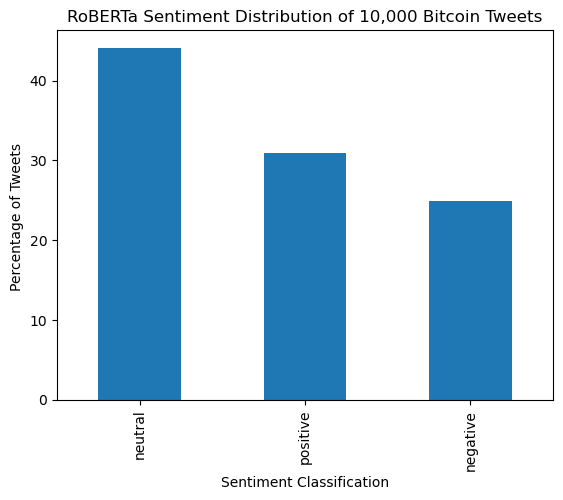

In [26]:
roberta_counts.plot(kind="bar")

plt.title("RoBERTa Sentiment Distribution of 10,000 Bitcoin Tweets")
plt.xlabel("Sentiment Classification")
plt.ylabel("Percentage of Tweets ")
plt.show()

## VADER Sentiment Distribution

In [14]:
# Percentage of VADER sentiment according to classification
vader_counts = df["vader_sentiment"].value_counts(normalize=True) * 100

vader_counts

vader_sentiment
positive    48.794408
neutral     28.519138
negative    22.686454
Name: proportion, dtype: float64

## Visualisation

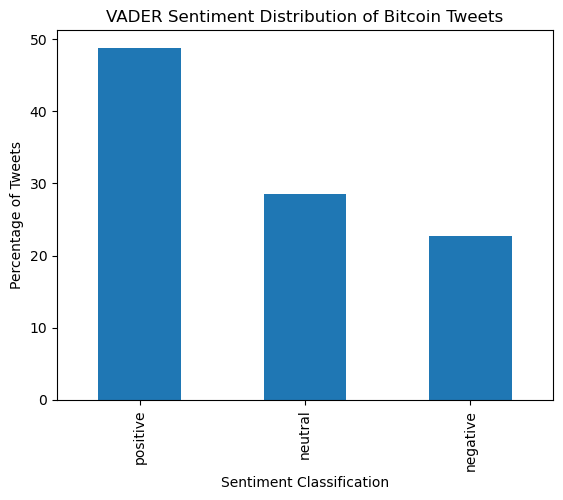

In [15]:
vader_counts.plot(kind="bar")

plt.title("VADER Sentiment Distribution of Bitcoin Tweets")
plt.xlabel("Sentiment Classification")
plt.ylabel("Percentage of Tweets")
plt.show()

## VADER Sentiment Distribution By Month

/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_31757/2791113698.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M")


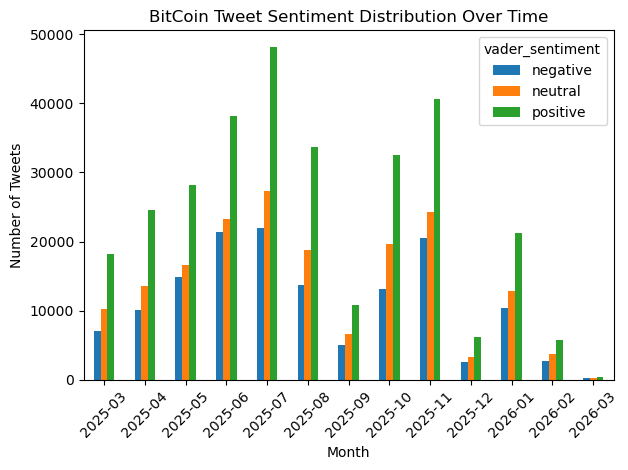

In [16]:
# add column to df for year-month
df["month"] = df["date"].dt.to_period("M")

monthly_vader_distribution = (
    df.set_index("date")
    .groupby(["month", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
)

monthly_vader_distribution.plot(kind="bar")
plt.title("BitCoin Tweet Sentiment Distribution Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## VADER Average Monthly Sentiment

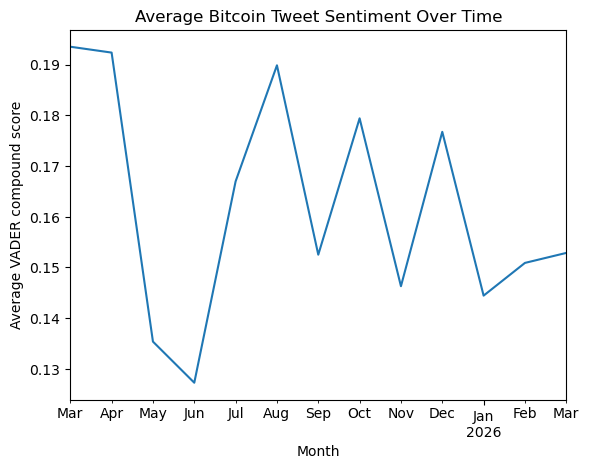

In [21]:
monthly_vader = (
    df.set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)

monthly_vader.plot()

plt.title("Average Bitcoin Tweet Sentiment Over Time")
plt.xlabel("Month")
plt.ylabel("Average VADER compound score")
plt.show()

## Sentiment By User Verification

Number of verified users: 4773
Number of unverified users: 627406


Text(0, 0.5, 'Average VADER compound score')

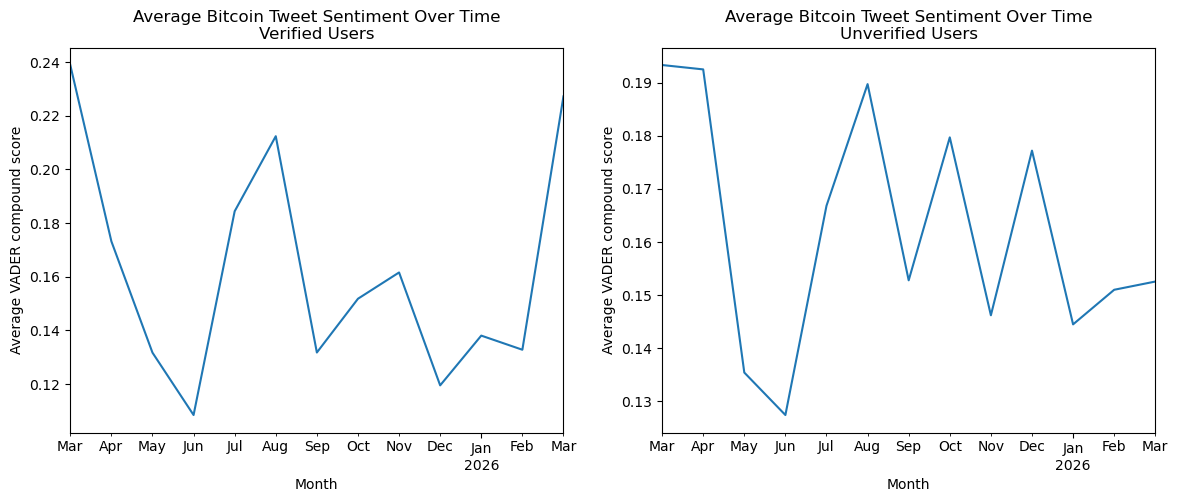

In [17]:
# dataframe of only verified users
verified_df = df[df["user_verified"] == True]

# dataframe of only unverified users
unverified_df = df[df["user_verified"] == False]

print(f'Number of verified users: {len(verified_df)}')

print(f'Number of unverified users: {len(unverified_df)}')

verified_df.head()

# monthly average sentiment for verified users
verified_monthly_vader = (
    verified_df.set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)
# monthly average sentiment for unverified users
unverified_monthly_vader = (
    unverified_df.set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)

fig, axes = plt.subplots(1,2, figsize=(14,5))

verified_monthly_vader.plot(ax=axes[0])
axes[0].set_title("Average Bitcoin Tweet Sentiment Over Time\nVerified Users")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average VADER compound score")

unverified_monthly_vader.plot(ax=axes[1])
axes[1].set_title("Average Bitcoin Tweet Sentiment Over Time\nUnverified Users")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average VADER compound score")


## Sentiment Distribution by Follower Count

In [18]:
# copy of original df
follower_df = df.copy()

# ensure user_followers is numeric
follower_df["user_followers"] = pd.to_numeric(
    follower_df["user_followers"],
    errors="coerce"
)

# create follower tiers
bins = [0, 1000, 10000, 50000, 500000, 1000000, float("inf")]

# follower tier labels
labels = [
    "Under 1k",
    "Nano: 1k - 10k",
    "Micro: 10k - 50k",
    "Mid-tier: 50k - 500k",
    "Macro: 500k - 1M",
    "Mega: 1M+"
]

# create column for follower tier
# assigns tier depending on the range that the user_followers count falls in

follower_df["follower_tier"] = pd.cut(
    follower_df["user_followers"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tier_counts = (
    follower_df
    .groupby(["follower_tier", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
)

# percentage conversion
tier_percent = (
    tier_counts
    .div(tier_counts.sum(axis=1), axis=0) * 100
)


tier_counts

/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_31757/3264881741.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["follower_tier", "vader_sentiment"])


vader_sentiment,negative,neutral,positive
follower_tier,,,
Under 1k,112888,142401,237483
Nano: 1k - 10k,23745,28428,55478
Micro: 10k - 50k,4842,6660,11448
Mid-tier: 50k - 500k,1850,2599,3824
Macro: 500k - 1M,63,121,133
Mega: 1M+,31,83,102


## Visualisation

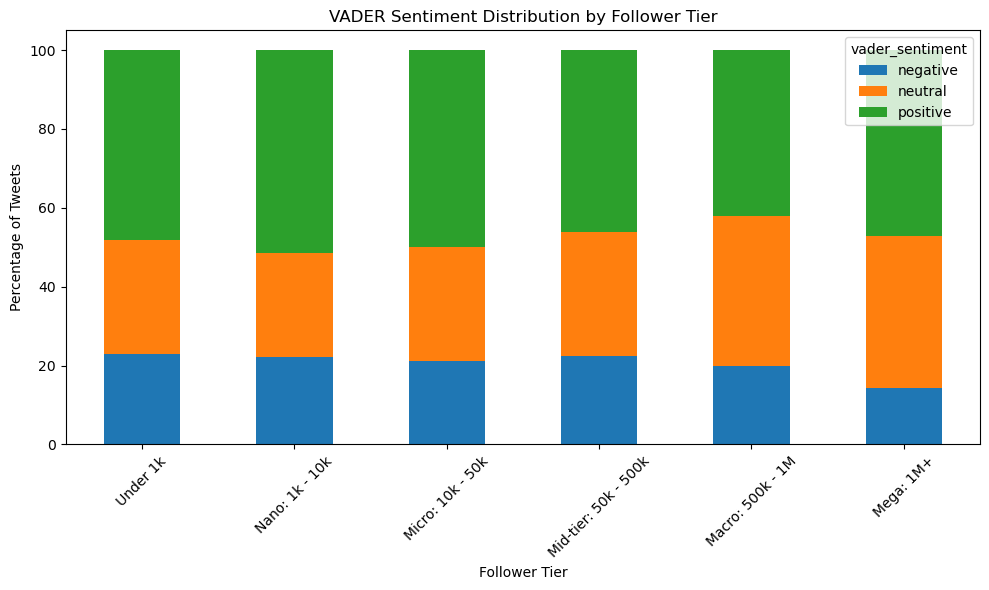

In [19]:
tier_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)
plt.title("VADER Sentiment Distribution by Follower Tier")
plt.xlabel("Follower Tier")
plt.ylabel("Percentage of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Average VADER Sentiment by Follower Tier

In [20]:
avg_vader_by_tier = (
    follower_df
    .groupby("follower_tier")["vader_compound"]
    .mean()
    .reset_index()
)

avg_vader_by_tier

/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_31757/1419061194.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("follower_tier")["vader_compound"]


,follower_tier,vader_compound
0,Under 1k,0.153650
1,Nano: 1k - 10k,0.192972
2,Micro: 10k - 50k,0.175690
3,Mid-tier: 50k - 500k,0.132202
4,Macro: 500k - 1M,0.103105
5,Mega: 1M+,0.176956


## Visualisation

In [17]:
plt.figure(figsize=(14, 6))

plt.bar(
    avg_vader_by_tier["follower_tier"].astype(str),
    avg_vader_by_tier["vader_compound"]
)

plt.title("Average VADER Compound Score by Follower Tier")
plt.xlabel("Follower Tier")
plt.ylabel("Average VADER Compound Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'avg_vader_by_tier' is not defined

<Figure size 1400x600 with 0 Axes>

## Sentiment Distribution by Topic

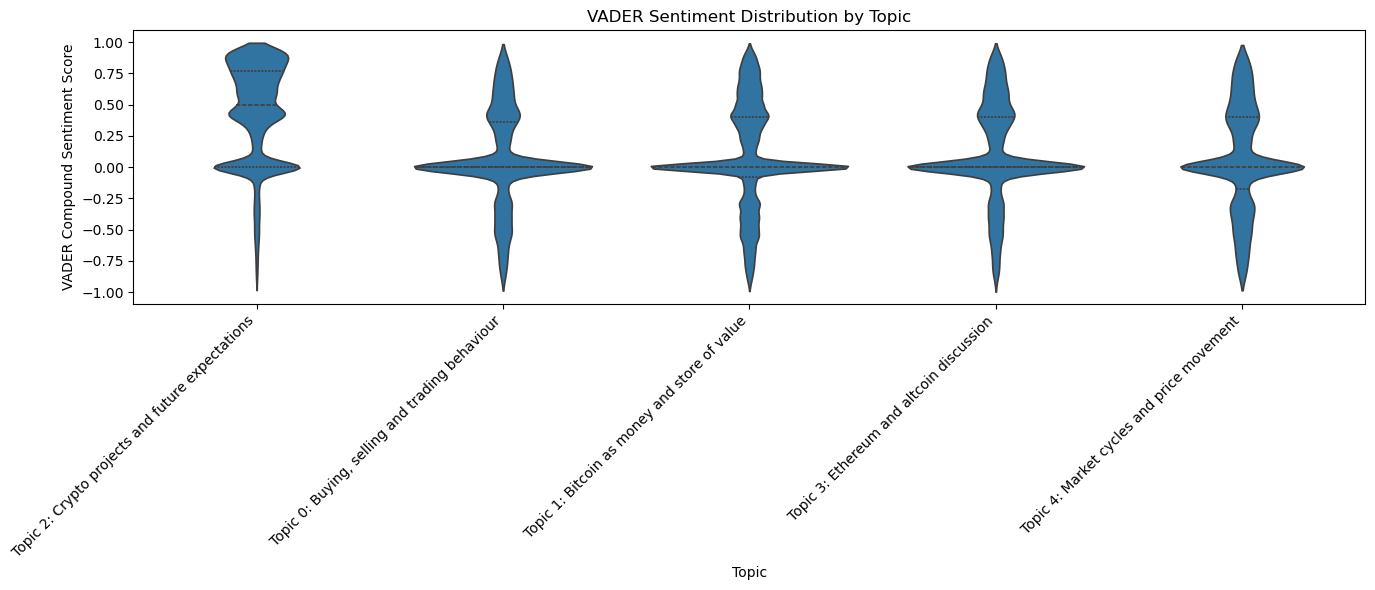

In [14]:
df["topic_display"] = (
    "Topic " + df["dominant_topic"].astype(str) + ": " + df["topic_label"].astype(str)
)

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="topic_display",
    y="vader_compound",
    inner="quartile",
    cut=0,
)

plt.title("VADER Sentiment Distribution by Topic")
plt.xlabel("Topic")
plt.ylabel("VADER Compound Sentiment Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Average VADER Score Per Topic

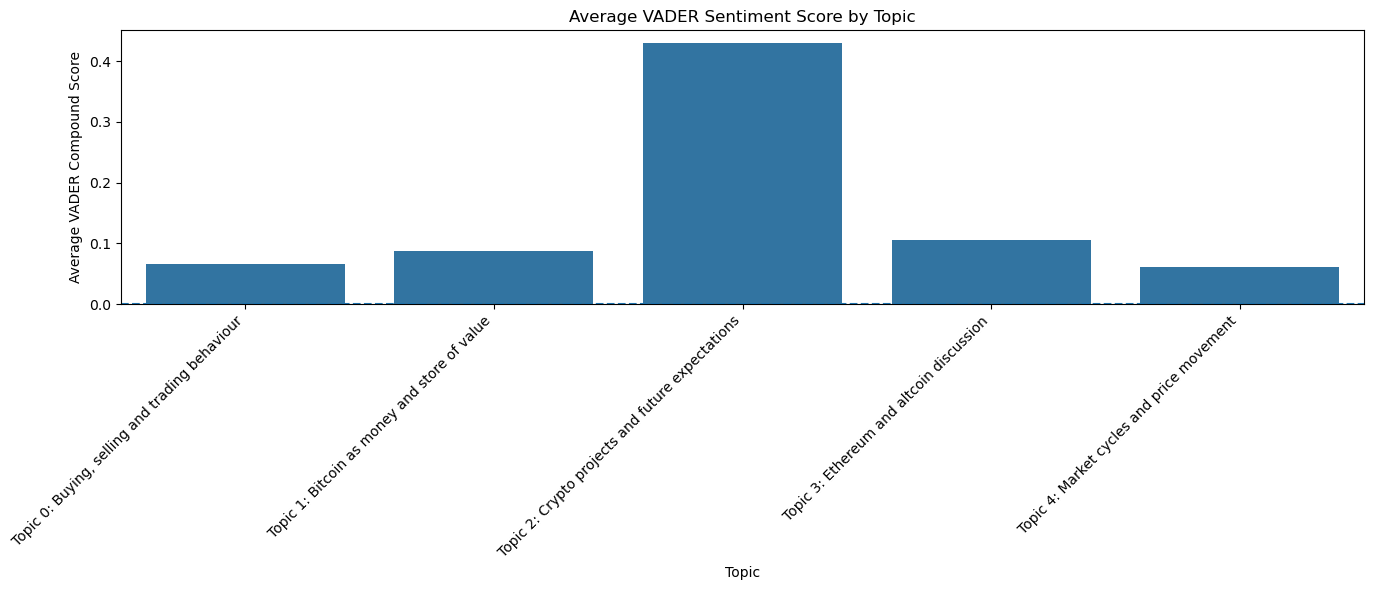

In [18]:
plt.figure(figsize=(14, 6))

topic_avg_vader = (
    df
    .groupby(["topic_display"])["vader_compound"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=topic_avg_vader,
    x="topic_display",
    y="vader_compound"
)

plt.title("Average VADER Sentiment Score by Topic")
plt.xlabel("Topic")
plt.ylabel("Average VADER Compound Score")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Statistical Test

In [20]:
topic_groups = [
    group["vader_compound"].dropna()
    for _, group in df.groupby("topic_display")
]

kruskal_result = kruskal(*topic_groups)

print("Kruskal-Wallis Test")
print("H-statistic:", kruskal_result.statistic)
print("p-value:", kruskal_result.pvalue)


if kruskal_result.pvalue < 0.05:
    print("There is a statistically significant difference in sentiment between topics.")
else:
    print("There is no statistically significant difference in sentiment between topics.")

Kruskal-Wallis Test
H-statistic: 29319.819232018832
p-value: 0.0
There is a statistically significant difference in sentiment between topics.


## Export enriched dataset with Sentiment

In [28]:
bitcoin_tweet_with_topics_sentiment = df.copy()

output_file = Path("data/bitcoin_tweet_with_topics_sentiment.parquet")

bitcoin_tweet_with_topics_sentiment.to_parquet(output_file, index=False)

print("Export complete.")
print("Saved file:", output_file)
print("Rows exported:", len(bitcoin_tweet_with_topics_sentiment))
print("Columns exported:")
print(bitcoin_tweet_with_topics_sentiment.columns.tolist())

Export complete.
Saved file: data/bitcoin_tweet_with_topics_sentiment.parquet
Rows exported: 627360
Columns exported:
['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'text_clean', 'hashtags', 'mentions', 'account_age_days', 'dominant_topic', 'topic_label', 'topic_strength', 'topic_confidence', 'vader_compound', 'vader_sentiment', 'topic_display']
